In [69]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import ase
from ase.visualize.plot import plot_atoms

In [32]:
folder = '/l/data/nnUNet_preprocessed/Dataset300_AFMRebias10/nnUNetPlans_2d/'
files = [
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.endswith('npz')
]

FileNotFoundError: [Errno 2] No such file or directory: '/l/data/nnUNet_preprocessed/Dataset300_AFMRebias10/nnUNetPlans_2d/'

In [3]:
print(len(files))
print(files[0])

99358
/l/data/nnUNet_preprocessed/Dataset300_AFMRebias10/nnUNetPlans_2d/afm_002724.npz


In [4]:
d = np.load(files[0])
x = d['data']
y = d['seg']

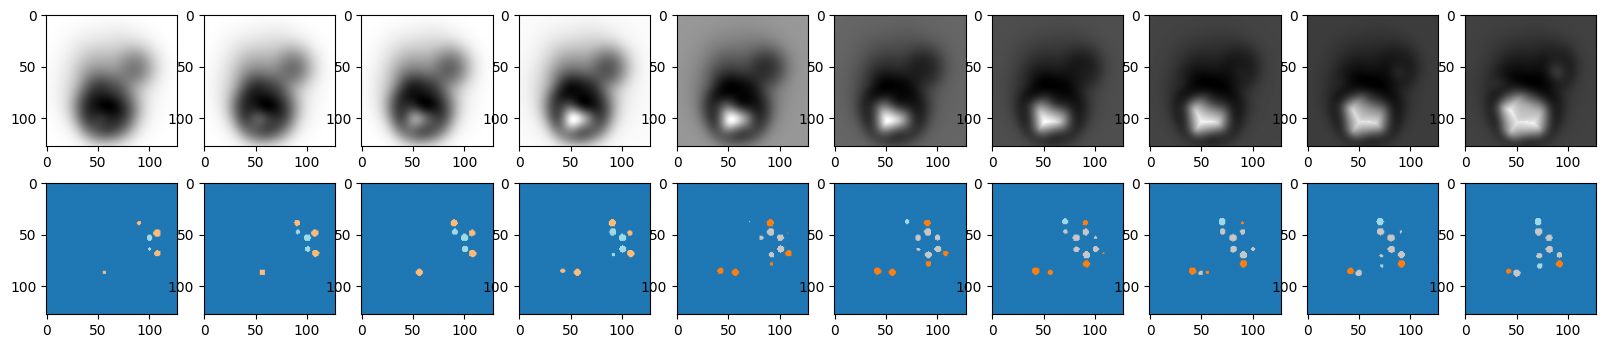

In [5]:
plt.figure(figsize=(20, 4))
for i in range(10):
    ax = plt.subplot(2, 10, i+1)
    ax.imshow(x[0, i], cmap='gray')

    ax = plt.subplot(2, 10, i+11)
    ax.imshow(y[0, i], cmap='tab20')


## Dataloader check

In [33]:
from nnunetv2.dataset_conversion.Dataset300_AFM import get_dataloader

2025-01-31 11:26:30.616197: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-31 11:26:30.617553: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-31 11:26:30.643670: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-31 11:26:30.644120: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-31 11:26:35.322173: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
nnUNet_results is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.


In [34]:
tf_data_folder = "/l/data/molnet/afms_rebias"
ds = get_dataloader(tf_data_folder)
sample = next(ds)

2025-01-31 11:26:43.845196: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-31 11:26:43.886917: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
[libprotobuf ERROR external/com_google_protobuf/src/google/protobuf/text_format.cc:337] Error parsing text-format tensorflow.data.experimental.DistributedSnapshotMetadata: 1:1: Invalid control characters encountered in text.
[libprotobuf ERROR external/com_google_pr

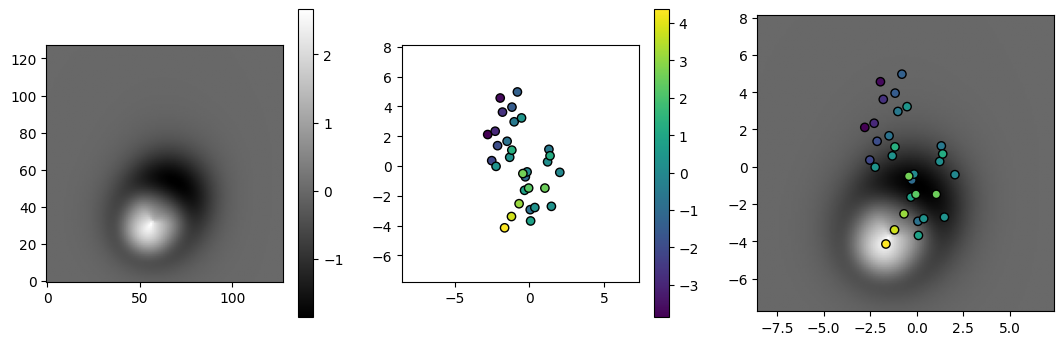

In [93]:
plt.figure(figsize=(13, 4))
ax = plt.subplot(131)
im = ax.imshow(sample['x'][..., -1], cmap='gray', origin='lower')
plt.colorbar(im)

xyz = sample['xyz']
xyz = xyz[xyz[:, -1] > 0]
# sort xyz by z
xyz = xyz[xyz[:, 2].argsort()]

ax = plt.subplot(132)
im = ax.scatter(xyz[:, 0], xyz[:, 1], c=xyz[:, 2], cmap='viridis', edgecolors='k')

sw = sample['sw']
ax.set_xlim(sw[0,0], sw[1,0])
ax.set_ylim(sw[0,1], sw[1,1])
ax.set_aspect('equal')
plt.colorbar(im)

ax = plt.subplot(133)
# Plot on the same axis
im = ax.imshow(sample['x'][..., -1], cmap='gray', origin='lower', extent=[sw[0,0], sw[1,0], sw[0,1], sw[1,1]])
im = ax.scatter(xyz[:, 0], xyz[:, 1], c=xyz[:, 2], cmap='viridis', edgecolors='k')




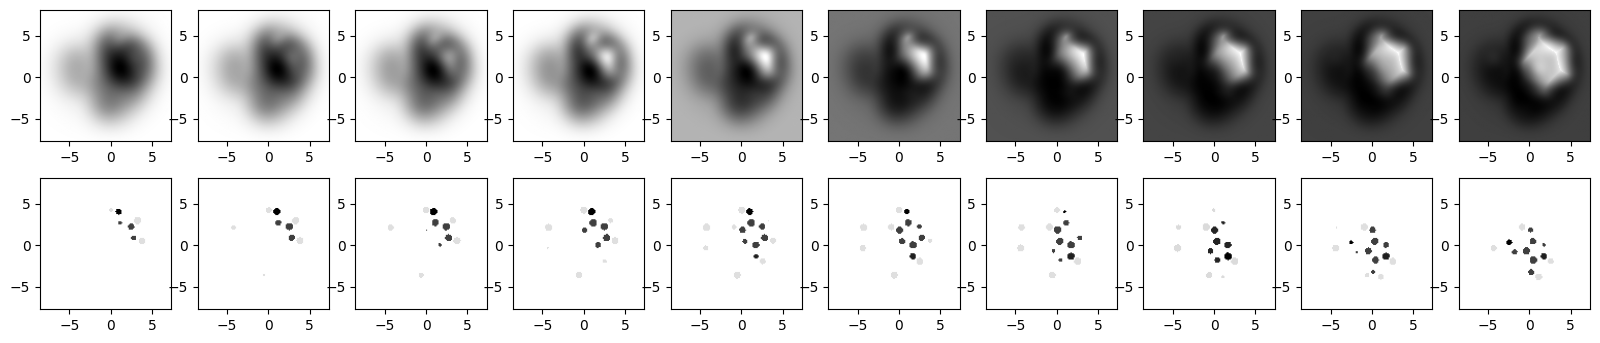

In [102]:
fig = plt.figure(figsize=(20, 4))
sample = next(ds)
x = sample['x']
y = sample['seg']
xyz = sample['xyz']

for i in range(10):
    ax = plt.subplot(2, 10, i+1)
    ax.imshow(x[..., i], cmap='gray', origin='lower', extent=[sw[0,0], sw[1,0], sw[0,1], sw[1,1]])

    ax = plt.subplot(2, 10, i+11)
    ax.imshow(y[..., i], cmap="binary", origin='lower', extent=[sw[0,0], sw[1,0], sw[0,1], sw[1,1]])

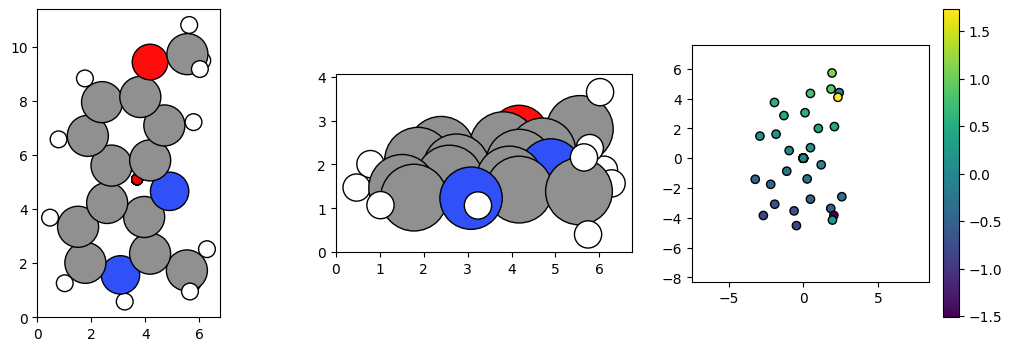

In [88]:
fig = plt.figure(figsize=(13, 4))
mol = ase.Atoms(
    positions=xyz[:, :3],
    numbers=xyz[:, -1]
)

ax = plt.subplot(131)
plot_atoms(mol, ax)

ax = plt.subplot(132)
# side view
plot_atoms(mol, ax, rotation='-90x,0y')

ax = plt.subplot(133)
im = ax.scatter(xyz[:, 0], xyz[:, 1], c=xyz[:, 2], cmap='viridis', edgecolors='k')
ax.set_xlim(sw[0,0], sw[1,0])
ax.set_ylim(sw[0,1], sw[1,1])
ax.set_aspect('equal')
plt.colorbar(im)


In [103]:
def get_data(index):
    with h5py.File("/u/79/kurkil1/unix/work/data/afm/afm.h5") as f:
        trainset = f["train"]
        X = trainset["X"][index, 0].transpose(1, 0, 2)

        sw = trainset["sw"][index, 0]
        xyz = trainset["xyz"][index]

        xyz = xyz[xyz[:, -1] > 0]

        return X, sw, xyz
    

In [104]:
x, sw, xyz = get_data(0)
mol = ase.Atoms(
    positions=xyz[:, :3],
    numbers=xyz[:, -1]
)

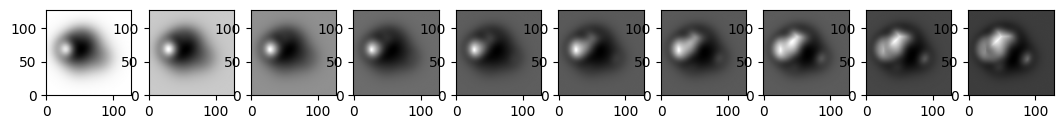

In [105]:
plt.figure(figsize=(13, 4))
for i in range(10):
    ax = plt.subplot(1, 10, i+1)
    ax.imshow(x[..., i], cmap='gray', origin='lower')

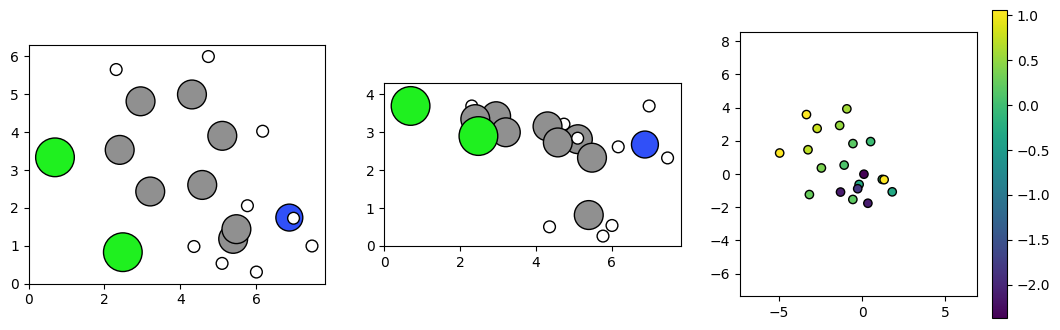

In [106]:
fig = plt.figure(figsize=(13, 4))
ax = plt.subplot(131)
plot_atoms(mol, ax, radii=0.5, rotation=('0x,0y,0z'))

ax = plt.subplot(132)
# side view
plot_atoms(mol, ax, radii=0.5, rotation=('-90x,0y,0z'))

ax = plt.subplot(133)
im = ax.scatter(xyz[:, 0], xyz[:, 1], c=xyz[:, 2], cmap='viridis', edgecolors='k')
ax.set_xlim(sw[0,1], sw[1,0])
ax.set_ylim(sw[0,1], sw[1,1])
ax.set_aspect('equal')
plt.colorbar(im)
